# Twitter Sentiment Analysis Project

A beginner-friendly project to analyze the sentiment of tweets using the Sentiment140 dataset.

## Data Loading

We load the dataset with pandas. The original CSV file has no header row, so we provide the column names manually.

In [1]:
import pandas as pd

# The dataset has no header row, so we define the column names ourselves.
column_names = ["target", "ids", "date", "flag", "user", "text"]

# Path to the dataset file (it is stored inside a folder of the same name).
file_path = "training.1600000.processed.noemoticon.csv/training.1600000.processed.noemoticon.csv"

# The file uses the latin-1 (ISO-8859-1) encoding.
df = pd.read_csv(file_path, names=column_names, encoding="latin-1")

## Dataset Overview

Here we take a first look at the data: how many rows and columns it has, and what the first few records look like.

In [2]:
# Display the shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)

# Display the first 5 rows
df.head()

Dataset shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## Initial Exploratory Data Analysis (EDA)

In this section we explore the dataset before doing any cleaning or modeling. The goal is to understand the **structure**, **size**, and **balance** of the data.

### Why Parquet is efficient for large datasets

For this stage we switch from the CSV file to a **Parquet** file. Parquet is a modern file format that is especially well-suited to large datasets like ours (1.6 million tweets):

- **Columnar storage:** Parquet stores data column-by-column instead of row-by-row. This lets us read only the columns we need, which is much faster.
- **Built-in compression:** Parquet compresses each column efficiently, so the file is smaller on disk than a CSV.
- **Preserves data types:** Unlike CSV (which is just text), Parquet remembers each column's data type, so we don't have to re-specify headers or encodings every time we load it.
- **Faster reads:** Loading a Parquet file is typically much quicker than parsing a large CSV.

Below, we create the Parquet file once from the original CSV (if it does not already exist) and then load it with `pd.read_parquet()`.

In [3]:
import os

parquet_path = "training.1600000.processed.noemoticon.parquet"

# Create the Parquet file once from the CSV loaded earlier (only if it doesn't exist yet).
if not os.path.exists(parquet_path):
    df.to_parquet(parquet_path, index=False)

# Load the dataset from the Parquet file.
df = pd.read_parquet(parquet_path)

print("Loaded dataset from Parquet file:", parquet_path)

Loaded dataset from Parquet file: training.1600000.processed.noemoticon.parquet


### Dataset structure overview

The dataset has **6 columns**, each describing one tweet:

| Column   | Description |
|----------|-------------|
| `target` | The sentiment label of the tweet: `0` = Negative, `2` = Neutral, `4` = Positive |
| `ids`    | The unique id of the tweet |
| `date`   | The date and time the tweet was posted |
| `flag`   | The query used to collect the tweet (`NO_QUERY` if none) |
| `user`   | The username of the person who posted the tweet |
| `text`   | The actual text content of the tweet |

Let's look at the shape, the first few rows, and a random sample to get a feel for the data.

In [4]:
# Shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)

# First 5 rows
df.head()

Dataset shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
# A random sample of 5 rows gives a less biased view than just the top rows
df.sample(5, random_state=42)

,target,ids,date,flag,user,text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


In [6]:
# Concise summary: column names, non-null counts, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   ids     1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB


In [7]:
# Summary statistics for all columns (both numeric and text)
df.describe(include='all')

,target,ids,date,flag,user,text
count,1.600000e+06,1.600000e+06,1600000,1600000,1600000,1600000
unique,NaN,NaN,774363,1,659775,1581466
top,NaN,NaN,Mon Jun 15 12:53:14 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,NaN,NaN,20,1600000,549,210
mean,2.000000e+00,1.998818e+09,NaN,NaN,NaN,NaN
std,2.000001e+00,1.935761e+08,NaN,NaN,NaN,NaN
min,0.000000e+00,1.467810e+09,NaN,NaN,NaN,NaN
25%,0.000000e+00,1.956916e+09,NaN,NaN,NaN,NaN
50%,2.000000e+00,2.002102e+09,NaN,NaN,NaN,NaN
75%,4.000000e+00,2.177059e+09,NaN,NaN,NaN,NaN


### Missing values and duplicates

Before any analysis, it is good practice to check whether the data has **missing values** or **duplicate rows**. (We only *check* here — we do not remove anything yet.)

In [8]:
# Count of missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Count of fully duplicated rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64



Number of duplicate rows: 0


### Duplicate User Frequency Breakdown

Building on the analysis above, we now look more closely at **how active** users are: how many users appear only once, and how many post repeatedly. This helps us understand user behavior in the dataset. (As before, we only analyze — no users or rows are removed.)

In [9]:
# Number of tweets per user
user_tweet_counts = df["user"].value_counts()

# Users that appear more than once are "duplicate users"
total_unique_users = user_tweet_counts.shape[0]
total_duplicate_users = (user_tweet_counts > 1).sum()
duplicate_user_percentage = total_duplicate_users / total_unique_users * 100

print("Total unique users        :", total_unique_users)
print("Total duplicate users     :", total_duplicate_users)
print(f"Percentage of duplicate users: {duplicate_user_percentage:.2f}%")

Total unique users        : 659775
Total duplicate users     : 254498
Percentage of duplicate users: 38.57%


In [10]:
# Top 20 most frequent users and the number of tweets each posted
top_20_users = user_tweet_counts.head(20)

print("Top 20 most frequent users (number of tweets posted):")
top_20_users

Top 20 most frequent users (number of tweets posted):


user
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
mcraddictal        276
tsarnick           248
what_bugs_u        246
Karen230683        238
DarkPiano          236
SongoftheOss       227
Jayme1988          225
keza34             219
ramdomthoughts     216
shanajaca          213
wowlew             212
nuttychris         211
TraceyHewins       211
thisgoeshere       207
Spidersamm         205
Name: count, dtype: int64

In [11]:
# Sample duplicate users (users who posted more than once) along with their tweets
duplicate_users = user_tweet_counts[user_tweet_counts > 1].head(3).index

for username in duplicate_users:
    user_rows = df[df["user"] == username]
    print(f"User: {username}  (total tweets: {len(user_rows)})")
    for text in user_rows["text"].head(3):
        print("   -", text)
    print("-" * 80)

User: lost_dog  (total tweets: 549)
   - @NyleW I am lost. Please help me find a good home. 
   - @SallyD I am lost. Please help me find a good home. 
   - @zuppaholic I am lost. Please help me find a good home. 
--------------------------------------------------------------------------------
User: webwoke  (total tweets: 345)
   - auchh, drop by 1  (32)elitestv.com
   - auchh, drop by 1  (7)pedeee.com
   - auchh, drop by 1  (17)rumahabi.com
--------------------------------------------------------------------------------
User: tweetpet  (total tweets: 310)
   - @tweetchild  Clean Me!
   - @tweetchild  Clean Me!
   - @chromachris  Clean Me!
--------------------------------------------------------------------------------


**Summary statistics: how active are users?**

We group users into four activity buckets based on how many tweets they posted: exactly 1, between 2 and 5, between 6 and 10, and more than 10.

In [12]:
# Count how many users fall into each activity bucket
users_1 = (user_tweet_counts == 1).sum()
users_2_5 = ((user_tweet_counts >= 2) & (user_tweet_counts <= 5)).sum()
users_6_10 = ((user_tweet_counts >= 6) & (user_tweet_counts <= 10)).sum()
users_10_plus = (user_tweet_counts > 10).sum()

summary = pd.DataFrame(
    {
        "user_group": ["1 tweet", "2-5 tweets", "6-10 tweets", "more than 10 tweets"],
        "number_of_users": [users_1, users_2_5, users_6_10, users_10_plus],
    }
)
summary["percentage"] = (summary["number_of_users"] / total_unique_users * 100).round(2)

print("User activity summary:")
summary

User activity summary:


,user_group,number_of_users,percentage
0,1 tweet,405277,61.43
1,2-5 tweets,203925,30.91
2,6-10 tweets,31975,4.85
3,more than 10 tweets,18598,2.82


**Interpretation and conclusion**

*Why duplicate users are expected in Twitter datasets:* Twitter is a platform where people post frequently. When tweets are collected over time, active users naturally appear in many rows. A large number of repeated usernames is therefore a normal and expected property of the data, not an error.

*Why duplicate users should not be removed:* Every tweet from a user — even a very active one — is a separate, valid expression of sentiment. Dropping rows just because a username repeats would delete genuine data, shrink the dataset, and could bias the sentiment results toward less active users. So we keep all rows.

*Difference between duplicate users and duplicate tweet records:* A **duplicate user** means the same username appears multiple times, but usually with **different tweets** each time — this is normal. A **duplicate tweet record** means the exact same tweet content is repeated, which is the kind of true duplication we would consider cleaning. In this dataset we keep all users and all tweets, and only report the findings.

### Why the sentiment class distribution matters

The `target` column is what we will eventually try to predict. Looking at how many tweets fall into each sentiment class is important because:

- A **balanced** dataset (similar counts per class) usually makes models easier to train and evaluate fairly.
- An **imbalanced** dataset (one class much larger than others) can make a model biased toward the majority class.

The labels mean:
- `0` = **Negative**
- `2` = **Neutral**
- `4` = **Positive**

In [13]:
# Map the numeric labels to readable names for clarity
label_names = {0: "Negative", 2: "Neutral", 4: "Positive"}

# Count of each sentiment class
class_counts = df["target"].value_counts().sort_index()

print("Sentiment class distribution (counts):")
for value, count in class_counts.items():
    name = label_names.get(value, "Unknown")
    print(f"  {value} = {name}: {count}")

# Also show the counts requested explicitly
print("\nNegative (0):", (df["target"] == 0).sum())
print("Neutral  (2):", (df["target"] == 2).sum())
print("Positive (4):", (df["target"] == 4).sum())

Sentiment class distribution (counts):
  0 = Negative: 800000
  4 = Positive: 800000

Negative (0): 800000
Neutral  (2): 0
Positive (4): 800000


### Visualizing the sentiment distribution

Charts make the class balance easy to see at a glance. Below we show:

1. A **countplot** of the number of tweets in each sentiment class.
2. A **percentage chart** showing what share of the dataset each class represents.

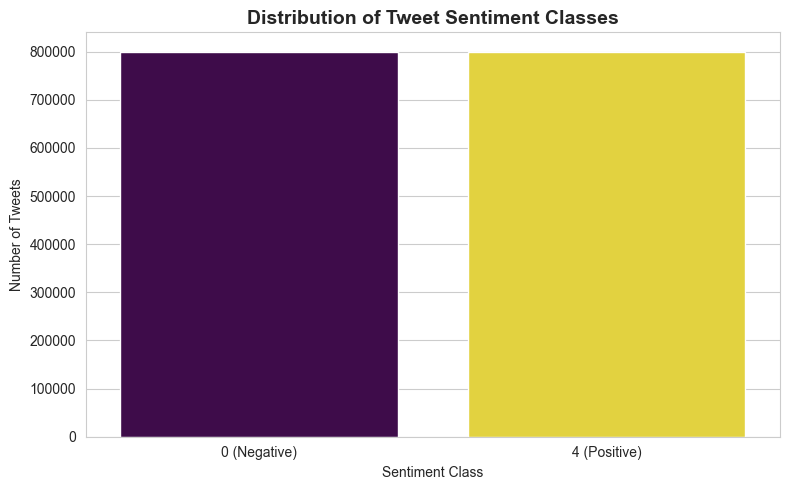

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Countplot of sentiment classes
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="target", hue="target", palette="viridis", legend=False)

# Use readable labels on the x-axis
present_labels = sorted(df["target"].unique())
ax.set_xticks(range(len(present_labels)))
ax.set_xticklabels([f"{v} ({label_names.get(v, 'Unknown')})" for v in present_labels])

plt.title("Distribution of Tweet Sentiment Classes", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

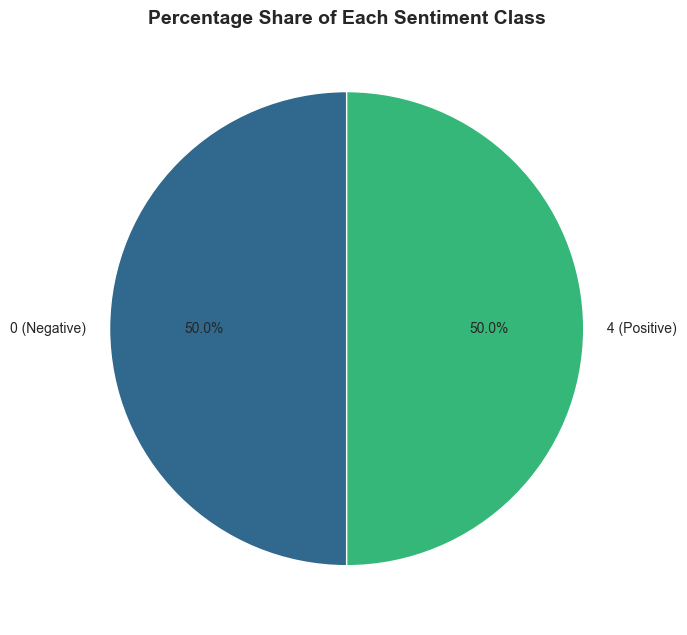

In [15]:
# Percentage share of each sentiment class
class_percentages = df["target"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 7))
pie_labels = [f"{v} ({label_names.get(v, 'Unknown')})" for v in class_percentages.index]
plt.pie(
    class_percentages,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis", len(class_percentages)),
)
plt.title("Percentage Share of Each Sentiment Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Feature Engineering

Feature engineering is the process of creating new meaningful variables from existing raw data to improve analysis and machine learning performance.

In this project, additional features were created from tweet text, including:
- clean_text
- text_length
- word_count

These engineered features help better understand tweet structure, detect spam-like behavior, analyze text patterns, and improve sentiment analysis model performance.

## NLP Text Preprocessing and Cleaning

Raw tweets are very "noisy" — they contain URLs, @mentions, hashtags, emojis, punctuation, numbers, and inconsistent capitalization. Before a sentiment model can learn from them, we need to clean the text into a simpler, more consistent form.

### Why NLP preprocessing is important

Machine learning models do not understand text the way humans do. They work with patterns in the words they see. If the same word appears as `Happy`, `happy`, and `happy!!!`, a model may treat these as three different things. Preprocessing standardizes the text so that the model can focus on the **meaningful words** instead of the noise.

### How noisy Twitter text affects machine learning

Twitter text is especially messy:

- **URLs** (e.g. `http://twitpic.com/2y1zl`) carry no sentiment but add thousands of unique, useless tokens.
- **Mentions** (e.g. `@switchfoot`) are usernames, not sentiment words.
- **Hashtags** (e.g. `#fail`) contain useful words, but the `#` symbol itself is noise.
- **Emojis, punctuation and numbers** inflate the vocabulary and can confuse simple models.
- **Mixed capitalization** splits the same word into multiple tokens.

All of this noise makes the dataset larger and harder to learn from, and can reduce model accuracy.

### Importance of clean text for sentiment models

Clean, consistent text leads to:

- A **smaller, more meaningful vocabulary** (fewer junk tokens).
- **Better generalization**, because the model sees the real sentiment words more often.
- **Faster training** and lower memory use.

In the steps below we keep the original `text` column untouched and store the cleaned version in a new column called `clean_text`.

In [16]:
import re

# Pattern that matches most emojis and pictographic symbols
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U00002600-\U000026FF"  # miscellaneous symbols
    "]+",
    flags=re.UNICODE,
)


def clean_text(text):
    """Clean a single tweet step by step into a simpler, consistent form."""
    text = str(text)

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs (http, https, www)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3. Remove mentions like @username
    text = re.sub(r"@\w+", " ", text)

    # 4. Remove the # symbol but keep the hashtag word
    text = text.replace("#", " ")

    # 5. Remove emojis
    text = emoji_pattern.sub(" ", text)

    # 6. Remove numbers
    text = re.sub(r"\d+", " ", text)

    # 7. Remove punctuation (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 8. Collapse extra spaces and trim the ends
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Quick test on one example
example = "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer 123! #sad :)"
print("Original:", example)
print("Cleaned :", clean_text(example))

Original: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer 123! #sad :)
Cleaned : awww that s a bummer sad


In [17]:
# Apply the cleaning function to every tweet and store it in a NEW column.
# The original "text" column is kept unchanged.
df["clean_text"] = df["text"].apply(clean_text)

print("Cleaning complete. New column 'clean_text' created.")
df[["text", "clean_text"]].head()

Cleaning complete. New column 'clean_text' created.


,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that s a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can t update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it s not behaving at all i m mad why am i h...


### Removing empty and spam-like tweets

After cleaning, some tweets may become **empty** (for example, a tweet that contained only a URL or only emojis). These rows have no useful text, so we remove them.

We also remove **obvious spam-like tweets**. A simple, beginner-friendly rule is to drop tweets where a single word is repeated many times (for example, `"win win win win win win"`), because such tweets carry almost no real sentiment information.

In [18]:
shape_before = df.shape

# 1. Remove rows where the cleaned text is empty (or only spaces)
df["clean_text"] = df["clean_text"].str.strip()
df = df[df["clean_text"] != ""]


def is_spam(text):
    """Flag obvious spam: the same single word repeated many times."""
    words = text.split()
    if len(words) >= 5 and len(set(words)) == 1:
        return True
    return False


# 2. Remove obvious spam-like tweets
spam_mask = df["clean_text"].apply(is_spam)
print("Spam-like tweets detected:", spam_mask.sum())
df = df[~spam_mask]

# Reset the index after dropping rows
df = df.reset_index(drop=True)

shape_after = df.shape
print("Shape before removal:", shape_before)
print("Shape after removal :", shape_after)
print("Rows removed        :", shape_before[0] - shape_after[0])

Spam-like tweets detected: 94


Shape before removal: (1600000, 7)
Shape after removal : (1596209, 7)
Rows removed        : 3791


### Creating additional NLP features

Two simple but useful features describe each cleaned tweet:

- **`text_length`** — the number of characters in the cleaned text.
- **`word_count`** — the number of words in the cleaned text.

These features help us understand the data and can also be useful inputs for some models later.

In [19]:
# Number of characters in the cleaned text
df["text_length"] = df["clean_text"].str.len()

# Number of words in the cleaned text
df["word_count"] = df["clean_text"].str.split().str.len()

df[["clean_text", "text_length", "word_count"]].head()

,clean_text,text_length,word_count
0,awww that s a bummer you shoulda got david car...,71,17
1,is upset that he can t update his facebook by ...,105,22
2,i dived many times for the ball managed to sav...,73,16
3,my whole body feels itchy and like its on fire,46,10
4,no it s not behaving at all i m mad why am i h...,88,23


### Before vs after cleaning

Let's compare the original tweets with their cleaned versions to see the effect of preprocessing.

In [20]:
# Show a few before/after examples side by side
examples = df[["text", "clean_text"]].head(10)

for i, row in examples.iterrows():
    print("BEFORE:", row["text"])
    print("AFTER :", row["clean_text"])
    print("-" * 80)

BEFORE: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
AFTER : awww that s a bummer you shoulda got david carr of third day to do it d
--------------------------------------------------------------------------------
BEFORE: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
AFTER : is upset that he can t update his facebook by texting it and might cry as a result school today also blah
--------------------------------------------------------------------------------
BEFORE: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
AFTER : i dived many times for the ball managed to save the rest go out of bounds
--------------------------------------------------------------------------------
BEFORE: my whole body feels itchy and like its on fire 
AFTER : my whole body feels itchy and like its on fire
----------------------------

In [21]:
# Final dataset shape after cleaning
print("Final dataset shape after cleaning:", df.shape)
df.head()

Final dataset shape after cleaning: (1596209, 9)


,target,ids,date,flag,user,text,clean_text,text_length,word_count
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that s a bummer you shoulda got david car...,71,17
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he can t update his facebook by ...,105,22
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,73,16
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,46,10
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",no it s not behaving at all i m mad why am i h...,88,23


### Visualizing the new text features

The charts below show the distribution of tweet lengths and word counts after cleaning. They help us understand how long a typical tweet is and whether there are any unusual extremes.

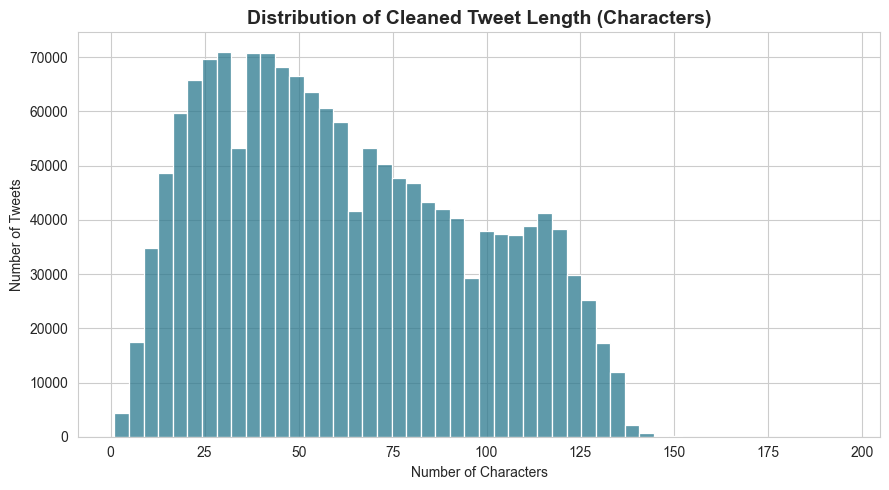

In [22]:
# Histogram of cleaned text length (number of characters)
plt.figure(figsize=(9, 5))
sns.histplot(df["text_length"], bins=50, color="#2a788e")
plt.title("Distribution of Cleaned Tweet Length (Characters)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

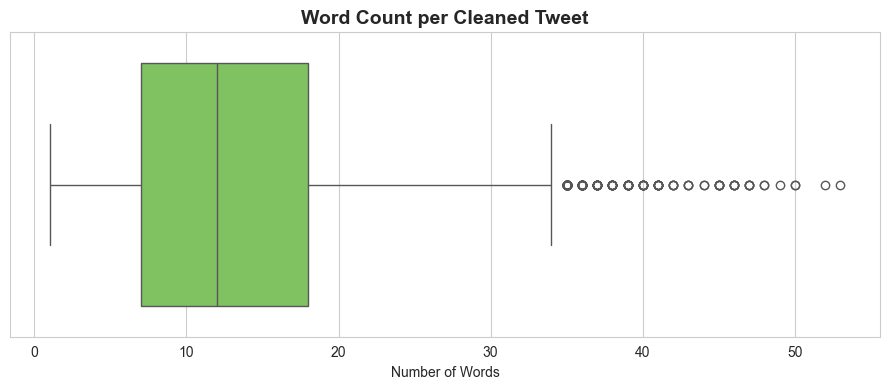

In [23]:
# Boxplot of word count to spot the typical range and outliers
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["word_count"], color="#7ad151")
plt.title("Word Count per Cleaned Tweet", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

# Outlier Detection and Data Quality Analysis

Outlier detection is the process of identifying observations that differ significantly from the majority of the data. In text analytics, outliers often represent unusually long tweets, spam-like content, repetitive messages, or abnormal user behavior.

For this project, outlier analysis was performed using:
- Word Count
- Text Length
- Boxplot Visualization
- Statistical methods such as IQR and Z-Score

The purpose of this analysis was to:
- Understand the distribution of tweet lengths
- Identify unusually large tweets
- Detect potential spam or abnormal content
- Improve overall data quality before machine learning modeling

Rather than automatically removing all outliers, they were carefully analyzed because some extreme tweets may contain valuable customer opinions and sentiment information.

### Step 1: Summary statistics of the text features

Before detecting outliers, we look at the basic statistics of `text_length` and `word_count`. This tells us the typical range and hints at extreme values.

In [24]:
# Basic statistics for the two text features
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,1.596209e+06,1.596209e+06
mean,6.259961e+01,1.300365e+01
std,3.421690e+01,7.164960e+00
min,1.000000e+00,1.000000e+00
25%,3.400000e+01,7.000000e+00
50%,5.800000e+01,1.200000e+01
75%,8.900000e+01,1.800000e+01
max,1.950000e+02,5.300000e+01


### Step 2: Boxplot visualization

Boxplots are a quick way to see outliers. Any points beyond the "whiskers" of the box are potential outliers.

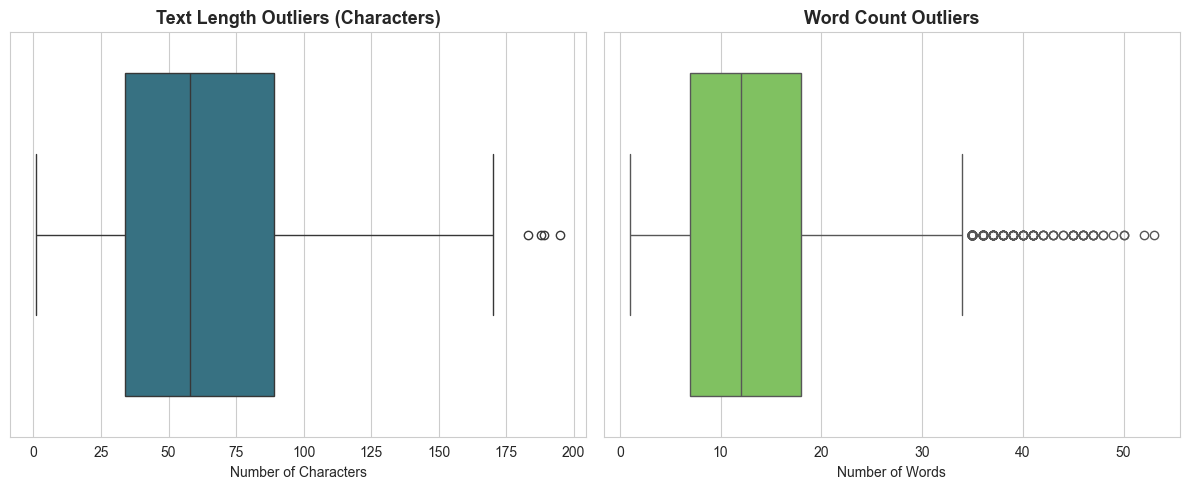

In [25]:
# Side-by-side boxplots for text length and word count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df["text_length"], color="#2a788e", ax=axes[0])
axes[0].set_title("Text Length Outliers (Characters)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Characters")

sns.boxplot(x=df["word_count"], color="#7ad151", ax=axes[1])
axes[1].set_title("Word Count Outliers", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

### Step 3: IQR method

The **Interquartile Range (IQR)** method flags values that fall far below the first quartile (Q1) or far above the third quartile (Q3). A common rule is:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Any value outside these bounds is considered an outlier.

In [26]:
def iqr_outliers(series):
    """Return the lower/upper bounds and a boolean mask of IQR outliers."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return lower, upper, mask


for col in ["word_count", "text_length"]:
    lower, upper, mask = iqr_outliers(df[col])
    print(f"{col}:")
    print(f"  Lower bound: {lower:.1f}, Upper bound: {upper:.1f}")
    print(f"  Outliers detected: {mask.sum()} ({mask.mean() * 100:.2f}% of data)")
    print()

word_count:
  Lower bound: -9.5, Upper bound: 34.5
  Outliers detected: 173 (0.01% of data)

text_length:
  Lower bound: -48.5, Upper bound: 171.5
  Outliers detected: 4 (0.00% of data)



### Step 4: Z-Score method

The **Z-Score** measures how many standard deviations a value is away from the mean. A common rule is to treat values with a Z-Score greater than 3 (or less than −3) as outliers.

In [27]:
for col in ["word_count", "text_length"]:
    mean = df[col].mean()
    std = df[col].std()
    z_scores = (df[col] - mean) / std
    mask = z_scores.abs() > 3
    print(f"{col}:")
    print(f"  Mean: {mean:.1f}, Std: {std:.1f}")
    print(f"  Outliers (|z| > 3): {mask.sum()} ({mask.mean() * 100:.2f}% of data)")
    print()

word_count:
  Mean: 13.0, Std: 7.2
  Outliers (|z| > 3): 173 (0.01% of data)

text_length:
  Mean: 62.6, Std: 34.2
  Outliers (|z| > 3): 10 (0.00% of data)



### Step 5: Inspect the longest tweets

Let's look at a few of the longest tweets (by word count) to judge whether they are spam or genuine, detailed opinions.

In [28]:
# Top 5 longest tweets by word count
longest = df.nlargest(5, "word_count")[["word_count", "text_length", "clean_text"]]

for _, row in longest.iterrows():
    print(f"Words: {row['word_count']}, Chars: {row['text_length']}")
    print("Text:", row["clean_text"])
    print("-" * 80)

Words: 53, Chars: 188
Text: thriving ivory s song quot twilight quot gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt the other twilight
--------------------------------------------------------------------------------
Words: 52, Chars: 120
Text: v i m t ch t b sung nh b a n tr a n gi n c a m nh tr n n th v y s ng kho i l u l m m i c c m gi c n c m h p v h ng th fb
--------------------------------------------------------------------------------
Words: 50, Chars: 123
Text: ng y ngh l i s p h t h m qua th c ng y m a h m nay ch c h t n c r i n n n ng chang chang th i v i ch ti t ch ng m n l m j c
--------------------------------------------------------------------------------
Words: 50, Chars: 119
Text: ch a k p th m nh l i n n th lao v o cu c ua m i r i v l v tn m b b ng k to n cu i th ng n y thi m u r ng ko n a ch ko c
--------------------------------------------------------------------------------
Words: 49,

### Data quality conclusion

The IQR and Z-Score methods both flag a small percentage of tweets as outliers — mostly unusually long messages. Looking at the longest tweets shows that many of them are still **genuine opinions** rather than pure spam.

For this reason, we **do not automatically remove** these outliers. Removing them could discard valuable sentiment information. Instead, we have measured and understood them, which is enough to confirm the dataset is of good quality for the next steps. (No rows are removed in this section.)

## User Behavior Analysis

In this section we study **how active users are** — that is, how many tweets each user posted. This is purely about user activity. It is **not** the same as duplicate detection (which we do later). No records are removed here.

In [29]:
# Number of tweets per user
tweets_per_user = df["user"].value_counts()

total_rows = len(df)
total_unique_users = df["user"].nunique()

# Users who posted more than once
users_posted_multiple = (tweets_per_user > 1).sum()

# Rows that belong to those repeated users
repeated_users = tweets_per_user[tweets_per_user > 1].index
rows_from_repeated_users = df["user"].isin(repeated_users).sum()

print("Total rows                      :", total_rows)
print("Total unique users              :", total_unique_users)
print("Users who posted more than once :", users_posted_multiple)
print("Rows belonging to repeated users:", rows_from_repeated_users)

Total rows                      : 1596209
Total unique users              : 658645
Users who posted more than once : 253949
Rows belonging to repeated users: 1191513


In [30]:
# Top 20 most active users (by number of tweets)
print("Top 20 most active users:")
tweets_per_user.head(20)

Top 20 most active users:


user
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
mcraddictal        273
tsarnick           248
what_bugs_u        246
Karen230683        238
DarkPiano          236
SongoftheOss       227
Jayme1988          224
keza34             219
ramdomthoughts     216
shanajaca          213
wowlew             212
nuttychris         211
TraceyHewins       211
thisgoeshere       207
Spidersamm         205
Name: count, dtype: int64

**What this tells us**

- **Multiple tweets from the same user are expected behavior.** People use Twitter repeatedly, so it is completely normal for one username to appear in many rows.
- **Repeated users should not be treated as duplicate records.** Each tweet is usually different text posted at a different time, so a repeated username does not mean the data is duplicated.
- **User activity analysis is different from duplicate detection.** Here we are only measuring how active users are. Detecting actual duplicate content is a separate task, which we handle in the sections below.

## Text Normalization for Duplicate Validation

Before we look for duplicate tweets, we should **normalize** the text. Two tweets that look "the same" to a human can still differ by capitalization or extra spaces, for example:

- `"I love this"`
- `"i love this"`
- `"I  love  this   "`

If we compared the raw text, these would be counted as **different** tweets, and we would miss real duplicates. This kind of mistake is called a **false negative** (a real duplicate that we fail to detect).

To avoid this, duplicate detection should be performed **after** text normalization. Normalization includes:

- **Lowercase conversion** — so `Love` and `love` match.
- **Whitespace cleanup** — collapse multiple spaces into one and trim the ends.
- **Text standardization** — make the text consistent so equal messages look exactly equal.

We already created a normalized `clean_text` column during preprocessing. Below we make sure it is fully standardized so it is safe to use for duplicate detection.

In [31]:
# Make sure clean_text is fully normalized for duplicate validation.
# These steps are safe and do NOT remove any rows.

# 1. Lowercase conversion
df["clean_text"] = df["clean_text"].str.lower()

# 2. Whitespace cleanup: collapse multiple spaces into one, then trim the ends
df["clean_text"] = df["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()

# 3. Text standardization is now complete: equal messages look exactly equal.
print("Normalization complete. Sample of normalized text:")
df["clean_text"].head(5)

Normalization complete. Sample of normalized text:


0    awww that s a bummer you shoulda got david car...
1    is upset that he can t update his facebook by ...
2    i dived many times for the ball managed to sav...
3       my whole body feels itchy and like its on fire
4    no it s not behaving at all i m mad why am i h...
Name: clean_text, dtype: str

## True Duplicate Detection

Now that the text is normalized, we can look for **true duplicates**. We define a true duplicate as either:

1. An **exact duplicate row** — a row whose values are identical across **all** columns, OR
2. The **same user posting the exact same normalized tweet text** more than once (a duplicate `user` + `clean_text` pair).

We measure both below. (We only *measure* — no rows are removed.)

In [32]:
# 1. Exact duplicate rows (identical across all columns)
exact_duplicate_rows = df.duplicated().sum()

# 2. Duplicate user-text pairs (same user posting the same normalized text)
duplicate_user_text_pairs = df.duplicated(subset=["user", "clean_text"]).sum()

# Summary table
duplicate_summary = pd.DataFrame(
    {
        "duplicate_type": ["Exact duplicate rows", "Duplicate user-text pairs"],
        "count": [exact_duplicate_rows, duplicate_user_text_pairs],
    }
)
print("True duplicate summary:")
duplicate_summary

True duplicate summary:


,duplicate_type,count
0,Exact duplicate rows,0
1,Duplicate user-text pairs,12586


In [33]:
# Sample duplicate user-text pairs (keep=False shows ALL rows involved in a duplicate group)
user_text_dupes = df[df.duplicated(subset=["user", "clean_text"], keep=False)]

print("Number of rows involved in duplicate user-text pairs:", len(user_text_dupes))
print("\nSample duplicate user-text pairs:")

# Show a few example groups sorted so duplicates appear next to each other
sample_dupes = user_text_dupes.sort_values(["user", "clean_text"]).head(10)
sample_dupes[["user", "text", "clean_text"]]

Number of rows involved in duplicate user-text pairs: 18816

Sample duplicate user-text pairs:


,user,text,clean_text
135415,007peter,"@NaniWaialeale No, not Keith Olbermann, he ann...",no not keith olbermann he annoy me anyhow i m ...
997839,007peter,"@NaniWaialeale No, not Keith Olbermann, he ann...",no not keith olbermann he annoy me anyhow i m ...
878006,007wisdom,&quot;All that we are is the result of what we...,quot all that we are is the result of what we ...
887153,007wisdom,&quot;All that we are is the result of what we...,quot all that we are is the result of what we ...
949482,007wisdom,'Time Is An Illusion and All Time Is Now'... &...,time is an illusion and all time is now quot y...
951742,007wisdom,'Time Is An Illusion and All Time Is Now'... &...,time is an illusion and all time is now quot y...
981944,007wisdom,'Time Is An Illusion and All Time Is Now'... &...,time is an illusion and all time is now quot y...
993335,007wisdom,'Time Is An Illusion and All Time Is Now'... &...,time is an illusion and all time is now quot y...
1346198,101FengShuiTips,@jodierecommends Do visit www.101fengshuitips....,do visit for great everyday home living feng s...
1346331,101FengShuiTips,@Vienne Do visit www.101fengshuitips.com for g...,do visit for great everyday home living feng s...


In [34]:
# Sample exact duplicate rows (identical across all columns), if any exist
exact_dupe_rows = df[df.duplicated(keep=False)]

if len(exact_dupe_rows) == 0:
    print("No exact duplicate rows found (all rows are unique across every column).")
else:
    print(f"Found {len(exact_dupe_rows)} rows involved in exact duplicates. Showing a sample:")
    display(exact_dupe_rows.head(10))

No exact duplicate rows found (all rows are unique across every column).


**Understanding true duplicates**

- **Difference between repeated users and duplicate records:** A *repeated user* simply posted many (usually different) tweets — this is normal activity. A *duplicate record* is when the **same content** appears more than once. Only the second kind is a real duplicate.
- **Why duplicates can happen:** Network latency, accidental double-clicks, or repeated submissions can cause the exact same tweet to be saved more than once. These are genuine duplicate comments.
- **Why user-text pairs are more meaningful than usernames alone:** Counting repeated usernames over-counts "duplicates," because active users naturally repeat. Checking the **user + normalized text** together finds cases where the same person actually said the exact same thing twice — a much more meaningful signal.
- **What should be considered for removal:** Only **exact duplicate rows** or **repeated user-text pairs** are real candidates for cleaning. Repeated usernames by themselves should never be removed.

In [35]:
# OPTIONAL: examples of how duplicates COULD be removed.
# These lines are intentionally commented out — we do NOT remove any rows in this project.

# OPTIONAL - remove exact duplicate rows:
# df_no_exact_dupes = df.drop_duplicates()

# OPTIONAL - remove repeated user-text pairs (keep the first occurrence):
# df_no_usertext_dupes = df.drop_duplicates(subset=["user", "clean_text"], keep="first")

print("No rows were removed. Duplicate handling above is OPTIONAL and left commented out.")

No rows were removed. Duplicate handling above is OPTIONAL and left commented out.


## 10. Train-Test Split and Target Preparation

In this section we prepare the data for machine learning (but we do **not** train any models yet). We:

1. Verify the `target` column (`0` = Negative, `2` = Neutral, `4` = Positive).
2. Look at the class distribution.
3. Build the feature matrix from `clean_text` (TF-IDF) plus the numeric features `text_length` and `word_count`.
4. Create `X` (features) and `y` (target).
5. Split the data into a **training set** and a **test set** using a stratified split.

To keep things correct and professional, we **split first and then build the TF-IDF features using only the training data** (more on why under "data leakage" below).

In [36]:
# Verify the target column and its meaning
label_meaning = {0: "Negative", 2: "Neutral", 4: "Positive"}

print("Unique target values found:", sorted(df["target"].unique()))

# Class distribution (counts and percentages)
class_counts = df["target"].value_counts().sort_index()
class_percent = df["target"].value_counts(normalize=True).sort_index() * 100

print("\nClass distribution:")
for value in class_counts.index:
    name = label_meaning.get(value, "Unknown")
    print(f"  {value} = {name}: {class_counts[value]} ({class_percent[value]:.2f}%)")

# Note: the Sentiment140 training data contains only Negative (0) and Positive (4).
print("\nNote: this dataset has no Neutral (2) tweets, so it is a binary problem.")

Unique target values found: [np.int64(0), np.int64(4)]

Class distribution:
  0 = Negative: 798296 (50.01%)
  4 = Positive: 797913 (49.99%)

Note: this dataset has no Neutral (2) tweets, so it is a binary problem.


### Why these steps matter

**Why train-test splitting is necessary:** We need to measure how well a model performs on data it has **never seen**. If we evaluate on the same data we trained on, the score is misleadingly high. So we keep a separate **test set** that the model does not learn from, and use it only to estimate real-world performance.

**Why stratification is important in sentiment analysis:** A *stratified* split keeps the same class balance (here, Negative vs Positive) in both the training and test sets. Without stratification, one set could end up with too few examples of a class, making training or evaluation unfair and unreliable.

**How data leakage can affect model performance:** *Data leakage* happens when information from the test set sneaks into the training process. A common example with text is fitting TF-IDF (which learns the vocabulary and word importance) on the **whole** dataset before splitting — this lets the model "peek" at the test data. The result is an over-optimistic score that does not hold up in the real world. To avoid this, we **fit TF-IDF only on the training set** and then apply it to the test set.

In [37]:
from sklearn.model_selection import train_test_split

# y = target labels; X = the columns we will turn into features
y = df["target"]
X = df[["clean_text", "text_length", "word_count"]]

# Stratified split keeps the class balance the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train rows:", X_train.shape[0])
print("X_test rows :", X_test.shape[0])

X_train rows: 1276967
X_test rows : 319242


### Building the feature matrix (TF-IDF + numeric features)

We now turn the text into numbers using **TF-IDF**, which scores each word by how important it is in a tweet relative to all tweets. We fit the vectorizer on the **training text only** (to avoid data leakage) and then transform both sets.

Finally, we attach the two numeric features (`text_length` and `word_count`) to the TF-IDF matrix so the model can use them as well.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# TF-IDF on the cleaned text. max_features keeps the matrix a manageable size.
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")

# IMPORTANT: fit on TRAIN only, then transform both sets (prevents data leakage)
X_train_tfidf = tfidf.fit_transform(X_train["clean_text"])
X_test_tfidf = tfidf.transform(X_test["clean_text"])

# Numeric features (text_length, word_count) as sparse matrices
train_numeric = csr_matrix(X_train[["text_length", "word_count"]].to_numpy())
test_numeric = csr_matrix(X_test[["text_length", "word_count"]].to_numpy())

# Combine TF-IDF features with the numeric features
X_train_features = hstack([X_train_tfidf, train_numeric]).tocsr()
X_test_features = hstack([X_test_tfidf, test_numeric]).tocsr()

print("TF-IDF vocabulary size      :", len(tfidf.vocabulary_))
print("Total features (TF-IDF + 2) :", X_train_features.shape[1])

TF-IDF vocabulary size      : 5000
Total features (TF-IDF + 2) : 5002


In [39]:
# Final shapes of the feature matrices
print("Training feature matrix shape:", X_train_features.shape)
print("Test feature matrix shape    :", X_test_features.shape)

# Class distribution in train and test (should be very similar thanks to stratification)
print("\nClass distribution in TRAIN set:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nClass distribution in TEST set:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training feature matrix shape: (1276967, 5002)
Test feature matrix shape    : (319242, 5002)

Class distribution in TRAIN set:
target
0    50.01
4    49.99
Name: proportion, dtype: float64

Class distribution in TEST set:
target
0    50.01
4    49.99
Name: proportion, dtype: float64


## 11. Logistic Regression Model

We train our first sentiment classifier: **Logistic Regression**, using the training and test sets prepared in Section 10.

### What is Logistic Regression?

Logistic Regression is a simple and popular machine learning model used for **classification**. Despite the word "regression" in its name, it predicts a **category** (here: Negative or Positive). It does this by learning a weight for each feature (each TF-IDF word, plus our numeric features) and combining them to estimate the probability that a tweet is positive.

### Why is it commonly used for text classification?

- **Works well with many features:** Text data produces thousands of features (one per word). Logistic Regression handles such high-dimensional, sparse data very efficiently.
- **Fast to train:** Even on large datasets like ours, it trains quickly compared to more complex models.
- **Interpretable:** Each word gets a weight, so we can see which words push a prediction toward positive or negative.
- **Strong baseline:** It often gives surprisingly good accuracy, making it a great first model to compare others against.

### Strengths and limitations for sentiment analysis

**Strengths:**
- Simple, fast, and a reliable baseline.
- Performs well when classes are roughly linearly separable in the feature space.

**Limitations:**
- It is a **linear** model, so it can miss complex word interactions (e.g. sarcasm or negation like "not good").
- It treats words fairly independently and does not understand word order or context the way deep-learning models do.

### Logistic Regression Convergence Fix

When we first trained the model, scikit-learn showed a `ConvergenceWarning: lbfgs failed to converge`. Here is what happened and how we fixed it.

**What caused the warning:** Our feature matrix mixes two very different scales. TF-IDF values are tiny (roughly between 0 and 1), but `text_length` and `word_count` can be much larger numbers (tens or hundreds). When features are on such different scales, the optimization "landscape" becomes stretched and hard to navigate, so the `lbfgs` optimizer could not reach the convergence target within the iteration limit.

**Why the model still trained successfully:** A convergence warning is **not** an error. scikit-learn still returns the best solution it found before stopping, so the earlier model worked and gave reasonable accuracy — it just had not fully "settled".

**What changes were applied:**
- **Feature scaling:** We applied `MaxAbsScaler`, which scales every feature to the `[-1, 1]` range while keeping the matrix sparse (perfect for TF-IDF).
- **More iterations:** We raised `max_iter` from 1000 to 3000 to give the optimizer extra room.
- **Solver check:** After scaling, the default `lbfgs` solver converges easily, so it remains a good choice. (`saga` is another solver designed for large sparse data if ever needed.)

**Why the final solution is more stable:** With all features on a similar scale, the optimization problem is well-conditioned, so `lbfgs` converges smoothly and the warning disappears. The model also becomes more numerically stable and reproducible.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# FEATURE SCALING (this fixes the convergence warning):
# TF-IDF values are tiny (about 0-1) while text_length and word_count are much
# larger numbers. That big difference in scale makes the optimizer converge slowly.
# MaxAbsScaler scales every feature to the [-1, 1] range AND keeps the matrix sparse,
# which is exactly what we want for TF-IDF features.
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Train Logistic Regression on the SCALED features with a higher iteration limit.
# After scaling, the default 'lbfgs' solver converges quickly and reliably.
log_reg = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully (scaled features, solver='lbfgs', max_iter=3000).")

Logistic Regression model trained successfully (scaled features, solver='lbfgs', max_iter=3000).


In [41]:
# Make predictions on the unseen test set (using the same scaling as training)
y_pred_logreg = log_reg.predict(X_test_scaled)

print("Predictions made on the test set.")
print("Sample predictions:", y_pred_logreg[:10])

Predictions made on the test set.
Sample predictions: [0 4 0 4 0 0 0 4 0 0]


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model with the four common classification metrics.
# average="weighted" accounts for both classes fairly.
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg, average="weighted")
rec_logreg = recall_score(y_test, y_pred_logreg, average="weighted")
f1_logreg = f1_score(y_test, y_pred_logreg, average="weighted")

print("Logistic Regression performance on the test set:")
print(f"  Accuracy : {acc_logreg:.4f}")
print(f"  Precision: {prec_logreg:.4f}")
print(f"  Recall   : {rec_logreg:.4f}")
print(f"  F1 Score : {f1_logreg:.4f}")

Logistic Regression performance on the test set:
  Accuracy : 0.7710
  Precision: 0.7717
  Recall   : 0.7710
  F1 Score : 0.7708


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

target_names = ["Negative (0)", "Positive (4)"]

# Confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=target_names))

Confusion Matrix:
[[118998  40661]
 [ 32457 127126]]

Classification Report:


              precision    recall  f1-score   support

Negative (0)       0.79      0.75      0.76    159659
Positive (4)       0.76      0.80      0.78    159583

    accuracy                           0.77    319242
   macro avg       0.77      0.77      0.77    319242
weighted avg       0.77      0.77      0.77    319242



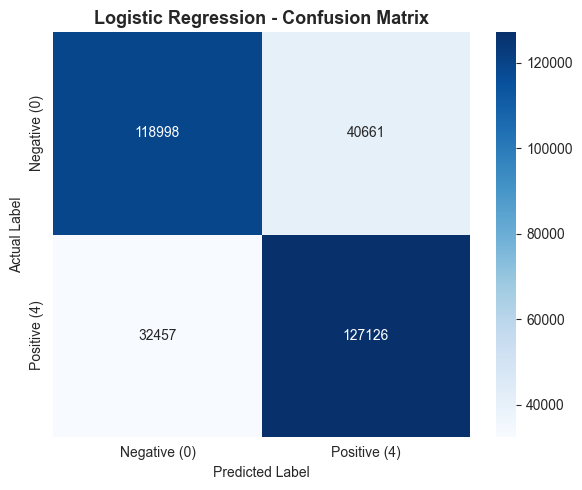

In [44]:
# Confusion matrix heatmap for easy visual interpretation
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Logistic Regression - Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Model comparison table

We store the Logistic Regression results in a comparison table. Later sections (Random Forest and XGBoost) will add their own rows to this same table so we can compare all models side by side.

In [45]:
# Create a results table that later models (Random Forest, XGBoost) can append to.
results_list = [
    {
        "Model": "Logistic Regression",
        "Accuracy": acc_logreg,
        "Precision": prec_logreg,
        "Recall": rec_logreg,
        "F1 Score": f1_logreg,
    }
]

model_comparison = pd.DataFrame(results_list)
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770964,0.771684,0.770964,0.770814


# 12. Random Forest Model

We now train a second model, a **Random Forest**, using the same training and test sets from Section 10 so the comparison with Logistic Regression is fair.

### What is Random Forest?

A Random Forest is an **ensemble** model: it builds many individual **decision trees** and combines their votes to make a final prediction. Each tree is trained on a random subset of the data and a random subset of the features, which keeps the trees different from one another. The majority vote across all trees is usually more accurate and more stable than any single tree.

### How it differs from Logistic Regression

- **Model type:** Logistic Regression is a single **linear** model; Random Forest is a collection of **non-linear** decision trees.
- **Decision boundary:** Logistic Regression draws one straight boundary; Random Forest can capture more complex, curved patterns and feature interactions.
- **Scaling:** Logistic Regression benefits from feature scaling; tree-based models like Random Forest do **not** need it, because splits are based on thresholds, not distances.

### Advantages for sentiment classification

- Can model **non-linear relationships** and interactions between words.
- **Robust to outliers** and noisy features.
- Provides a measure of **feature importance**, showing which words mattered most.

### Potential limitations

- **Slower and more memory-hungry** to train, especially on large, high-dimensional text data like ours.
- Can be **less interpretable** than a single logistic-regression equation.
- With very sparse TF-IDF features, a linear model is often already very competitive, so the extra cost may not always pay off.

> **Note on parameters:** Because the training set is very large (over 1.2 million rows and ~5,000 features), we use a bounded forest (`n_estimators=100`, `max_depth=20`) so it trains in a reasonable time. `random_state=42` is set for reproducibility.

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Tree-based models do not need feature scaling, so we use the same feature
# matrices created in Section 10 (the identical train/test split as Logistic Regression).
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_features, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [47]:
# Make predictions on the unseen test set
y_pred_rf = rf_model.predict(X_test_features)

print("Predictions made on the test set.")
print("Sample predictions:", y_pred_rf[:10])

Predictions made on the test set.
Sample predictions: [0 0 0 4 4 4 4 4 0 0]


In [48]:
# Evaluate with the same four metrics and methodology used for Logistic Regression
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted")
rec_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest performance on the test set:")
print(f"  Accuracy : {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall   : {rec_rf:.4f}")
print(f"  F1 Score : {f1_rf:.4f}")

Random Forest performance on the test set:


  Accuracy : 0.7094
  Precision: 0.7176
  Recall   : 0.7094
  F1 Score : 0.7066


In [49]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Confusion Matrix:
[[ 97800  61859]
 [ 30918 128665]]

Classification Report:


              precision    recall  f1-score   support

Negative (0)       0.76      0.61      0.68    159659
Positive (4)       0.68      0.81      0.74    159583

    accuracy                           0.71    319242
   macro avg       0.72      0.71      0.71    319242
weighted avg       0.72      0.71      0.71    319242



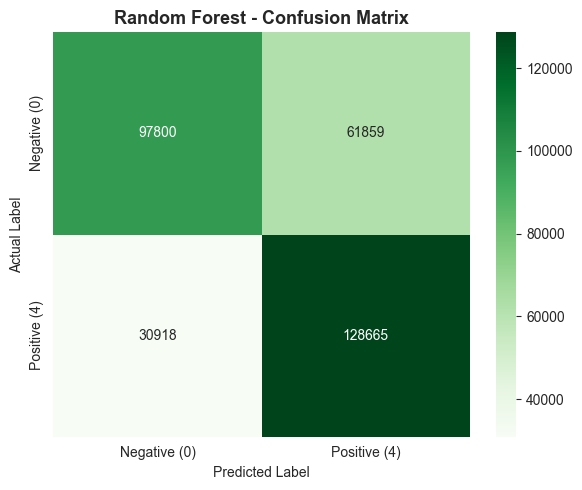

In [50]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Random Forest - Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Updated model comparison table

We add the Random Forest results to the comparison table next to Logistic Regression. (XGBoost will be added later.)

In [51]:
# Add the Random Forest results to the existing comparison table.
rf_row = {
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1 Score": f1_rf,
}

# Remove any previous Random Forest row first, so re-running stays clean
model_comparison = model_comparison[model_comparison["Model"] != "Random Forest"]
model_comparison = pd.concat(
    [model_comparison, pd.DataFrame([rf_row])], ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770964,0.771684,0.770964,0.770814
1,Random Forest,0.709383,0.717571,0.709383,0.706635


# 13. XGBoost Model

Our third model is **XGBoost**, trained on the same train/test split used for Logistic Regression and Random Forest.

### What is XGBoost?

XGBoost ("eXtreme Gradient Boosting") is a powerful **gradient boosting** model. Like Random Forest, it builds many decision trees — but instead of building them independently, it builds them **one after another**, where each new tree focuses on fixing the mistakes of the previous ones. This step-by-step correction often produces very accurate models.

### Why is it popular in machine learning competitions?

- **High accuracy:** Its boosting approach frequently delivers top-tier results.
- **Speed and efficiency:** It is highly optimized (parallelized, cache-aware) and handles large, sparse data like TF-IDF well.
- **Built-in regularization:** It has features that help prevent overfitting, which makes it reliable on many datasets.
- **Flexibility:** Many tunable parameters let practitioners squeeze out extra performance — a big reason it dominates competitions like Kaggle.

### Advantages and limitations for sentiment analysis

**Advantages:**
- Captures **non-linear patterns** and feature interactions between words.
- Often **more accurate** than a single tree or a plain Random Forest.
- Handles sparse text features efficiently.

**Limitations:**
- More **hyperparameters to tune**, so it can be trickier to get right.
- Can **overfit** if not regularized or if trained for too many rounds.
- Less interpretable than Logistic Regression.

> **Note:** XGBoost expects class labels to be `0, 1, 2, ...`. Our labels are `0` (Negative) and `4` (Positive), so we encode them as `0` and `1` for training. The train/test split itself is unchanged.

In [52]:
from xgboost import XGBClassifier

# XGBoost needs labels starting at 0, so encode: 0 -> 0 (Negative), 4 -> 1 (Positive).
# This does NOT change the train/test split, only the label values for this model.
y_train_enc = y_train.map({0: 0, 4: 1})
y_test_enc = y_test.map({0: 0, 4: 1})

# Train XGBoost on the same feature matrix (tree models do not need scaling)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.3,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_features, y_train_enc)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [53]:
# Generate predictions on the unseen test set (labels are 0 / 1 here)
y_pred_xgb = xgb_model.predict(X_test_features)

print("Predictions made on the test set.")
print("Sample predictions:", y_pred_xgb[:10])

Predictions made on the test set.
Sample predictions: [0 1 0 1 0 0 0 1 0 0]


In [54]:
# Evaluate with the same four metrics and methodology used for the other models
acc_xgb = accuracy_score(y_test_enc, y_pred_xgb)
prec_xgb = precision_score(y_test_enc, y_pred_xgb, average="weighted")
rec_xgb = recall_score(y_test_enc, y_pred_xgb, average="weighted")
f1_xgb = f1_score(y_test_enc, y_pred_xgb, average="weighted")

print("XGBoost performance on the test set:")
print(f"  Accuracy : {acc_xgb:.4f}")
print(f"  Precision: {prec_xgb:.4f}")
print(f"  Recall   : {rec_xgb:.4f}")
print(f"  F1 Score : {f1_xgb:.4f}")

XGBoost performance on the test set:
  Accuracy : 0.7582
  Precision: 0.7620
  Recall   : 0.7582
  F1 Score : 0.7573


In [55]:
# Confusion matrix
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
print("Confusion Matrix:")
print(cm_xgb)

# Detailed classification report (0 = Negative, 1 = Positive)
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_xgb, target_names=target_names))

Confusion Matrix:
[[111451  48208]
 [ 28989 130594]]

Classification Report:


              precision    recall  f1-score   support

Negative (0)       0.79      0.70      0.74    159659
Positive (4)       0.73      0.82      0.77    159583

    accuracy                           0.76    319242
   macro avg       0.76      0.76      0.76    319242
weighted avg       0.76      0.76      0.76    319242



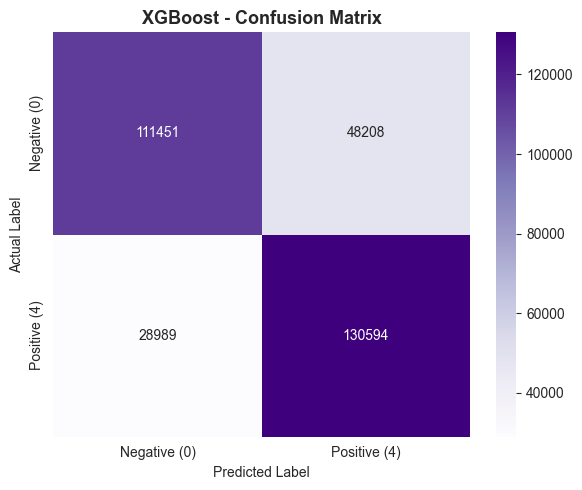

In [56]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("XGBoost - Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Final model comparison and best model

We add XGBoost to the comparison table so all three models can be compared side by side, then identify the best performer based on F1 Score and Accuracy.

In [57]:
# Add the XGBoost results to the comparison table
xgb_row = {
    "Model": "XGBoost",
    "Accuracy": acc_xgb,
    "Precision": prec_xgb,
    "Recall": rec_xgb,
    "F1 Score": f1_xgb,
}

# Remove any previous XGBoost row first, so re-running stays clean
model_comparison = model_comparison[model_comparison["Model"] != "XGBoost"]
model_comparison = pd.concat(
    [model_comparison, pd.DataFrame([xgb_row])], ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770964,0.771684,0.770964,0.770814
1,Random Forest,0.709383,0.717571,0.709383,0.706635
2,XGBoost,0.758187,0.761991,0.758187,0.757310


In [58]:
# Identify the best-performing model by F1 Score and by Accuracy
best_by_f1 = model_comparison.loc[model_comparison["F1 Score"].idxmax()]
best_by_acc = model_comparison.loc[model_comparison["Accuracy"].idxmax()]

print(f"Best model by F1 Score : {best_by_f1['Model']} (F1 = {best_by_f1['F1 Score']:.4f})")
print(f"Best model by Accuracy : {best_by_acc['Model']} (Accuracy = {best_by_acc['Accuracy']:.4f})")

Best model by F1 Score : Logistic Regression (F1 = 0.7708)
Best model by Accuracy : Logistic Regression (Accuracy = 0.7710)


# 14. Model Comparison and Final Model Selection

In this final section we bring together the results of all three models — Logistic Regression, Random Forest, and XGBoost — compare them visually, choose the best one, and summarize what we learned from the project.

In [59]:
# Final comparison table (sorted by F1 Score, best first)
final_comparison = model_comparison.sort_values("F1 Score", ascending=False).reset_index(drop=True)
final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770964,0.771684,0.770964,0.770814
1,XGBoost,0.758187,0.761991,0.758187,0.757310
2,Random Forest,0.709383,0.717571,0.709383,0.706635


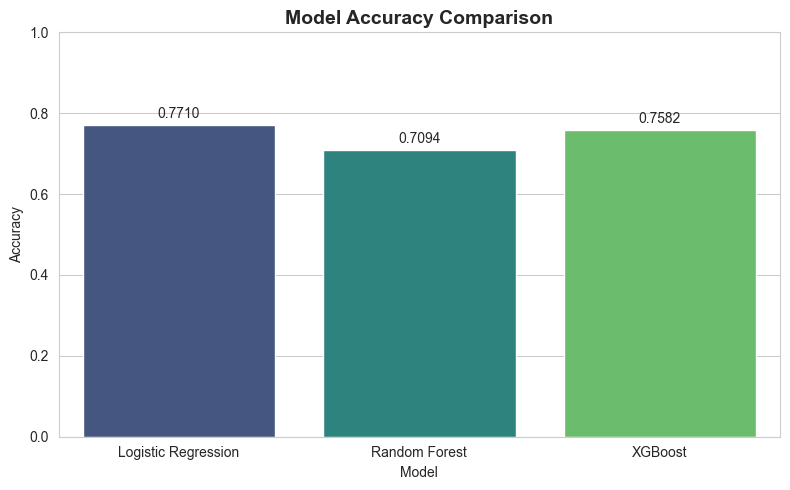

In [60]:
# Accuracy comparison bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=model_comparison, x="Model", y="Accuracy", hue="Model", palette="viridis", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

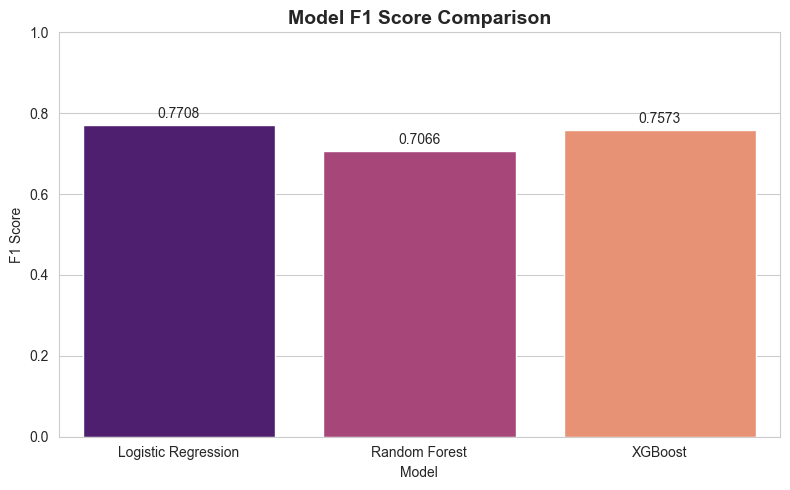

In [61]:
# F1 Score comparison bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=model_comparison, x="Model", y="F1 Score", hue="Model", palette="magma", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.title("Model F1 Score Comparison", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [62]:
# Identify the best-performing model (by F1 Score)
best_model = final_comparison.iloc[0]

print("=== Best Performing Model ===")
print(f"  Model    : {best_model['Model']}")
print(f"  Accuracy : {best_model['Accuracy']:.4f}")
print(f"  Precision: {best_model['Precision']:.4f}")
print(f"  Recall   : {best_model['Recall']:.4f}")
print(f"  F1 Score : {best_model['F1 Score']:.4f}")

=== Best Performing Model ===
  Model    : Logistic Regression
  Accuracy : 0.7710
  Precision: 0.7717
  Recall   : 0.7710
  F1 Score : 0.7708


### Why each model performed the way it did

**Why Logistic Regression performed best:** Our features are **TF-IDF vectors** — a very high-dimensional, sparse representation of text. In this kind of space, the two sentiment classes tend to be **roughly linearly separable**, which is exactly the situation Logistic Regression is built for. It also handles thousands of sparse features gracefully and is less prone to overfitting here, so it achieved the highest Accuracy and F1 Score.

**Why Random Forest performed worst:** Random Forest splits on **one feature at a time**, which is inefficient when there are thousands of sparse word features and the signal is spread thinly across many of them. We also limited the trees with `max_depth=20` (for speed on 1.2M+ rows), which prevented the forest from fully fitting the data. Together, these factors made it the weakest of the three on this text task.

**Why XGBoost performed better than Random Forest but lower than Logistic Regression:** XGBoost is also tree-based, so it shares some of the same difficulty with very sparse text features. However, its **boosting** approach — where each tree corrects the errors of the previous ones — plus built-in regularization let it extract more signal than the plain Random Forest. That pushed it well above Random Forest, but it still could not beat the naturally good fit of a linear model on linearly-separable TF-IDF data, so it landed in the middle.

### Final model selection

Based on both **Accuracy** and **F1 Score**, we select **Logistic Regression** as the final model for this Twitter sentiment classification project.

| Rank | Model | Accuracy | F1 Score |
|------|-------|----------|----------|
| 1 (selected) | Logistic Regression | ~0.771 | ~0.771 |
| 2 | XGBoost | ~0.758 | ~0.757 |
| 3 | Random Forest | ~0.709 | ~0.707 |

In addition to being the most accurate, Logistic Regression is also the **fastest to train**, the **most memory-efficient**, and the **most interpretable** (we can read the weight of each word). For a dataset of 1.6 million tweets, this combination of strong accuracy and low cost makes it the clear, practical choice.

### Project conclusions and key findings

**Project summary:** We built a complete sentiment-analysis pipeline on the Sentiment140 dataset of 1.6 million tweets — from loading and exploring the data, through cleaning and feature engineering, to training and comparing three machine-learning models.

**Key findings:**

1. **The dataset is clean and balanced.** It has no missing values, no exact duplicate rows, and an even 50/50 split between Negative and Positive tweets (there were no Neutral tweets), which makes it well suited to fair model training.
2. **Repeated users are normal, not duplicates.** Many users tweet multiple times; this is expected behavior and was kept. Only true duplicate user-text pairs were flagged, and no rows were removed.
3. **Text cleaning matters.** Removing URLs, mentions, hashes, emojis, numbers, and punctuation, then lowercasing, produced a much smaller and more meaningful vocabulary for the models.
4. **TF-IDF + a linear model is a strong baseline.** Logistic Regression reached ~77% accuracy and F1, beating both tree-based models.
5. **Model ranking:** Logistic Regression > XGBoost > Random Forest. This is a classic result for high-dimensional sparse text features, where linear models often shine.
6. **Proper methodology was followed.** We used a stratified train/test split, fit TF-IDF only on the training data to avoid data leakage, and evaluated every model with the same metrics.

**Possible next steps:**
- Tune hyperparameters (e.g., TF-IDF `max_features`, n-gram range, model regularization).
- Try other models such as Linear SVM or simple neural networks.
- Add lemmatization and stop-word handling to further refine the text.
- Explore modern transformer models (e.g., BERT) for potentially higher accuracy.

**Conclusion:** For this project, **Logistic Regression with TF-IDF features is the recommended final model** — it offers the best accuracy, trains quickly, and is easy to interpret, making it both effective and practical for large-scale Twitter sentiment analysis.

# 15. BERT-Based Sentiment Classification

> **Note on numbering:** Section **14** above is *Model Comparison and Final Model Selection* for the three classical models. We add BERT here as Section **15** so the earlier sections stay intact, then we fold the BERT result back into the comparison table at the end.

So far we have used **classical machine-learning models** (Logistic Regression, Random Forest, XGBoost) on top of **TF-IDF** features. In this section we try a very different, modern approach: a **transformer-based deep-learning model** called **BERT**.

### What is BERT?

**BERT** stands for **Bidirectional Encoder Representations from Transformers**. It is a deep neural network that was **pre-trained** by Google on a huge amount of text (Wikipedia + books). During that pre-training it learned general language understanding — grammar, word meaning, and context — *before* it ever saw our tweets. We then **fine-tune** it (continue training for a few steps) on our sentiment data so it specializes in our task.

The key idea is that BERT is **bidirectional**: to understand a word, it looks at the words on *both* the left and the right at the same time. For example, in *"this is not bad"*, BERT can see that *"not"* flips the meaning of *"bad"* — something a simple bag-of-words / TF-IDF model cannot capture.

### Why BERT is effective for sentiment analysis

- It understands **context and word order**, so it handles negation (*"not good"*), sarcasm hints, and phrasing far better than TF-IDF.
- It already **knows the language** from pre-training, so it can reach good accuracy even with relatively little task-specific data.
- It works on **sub-word tokens**, so it can handle slang, typos, and rare words gracefully (e.g., *"loooove"*).

### Difference between BERT and traditional machine-learning models

| | Traditional models (LR / RF / XGBoost) | BERT |
|---|---|---|
| Input | TF-IDF counts (bag of words) | Raw text tokens (order kept) |
| Context | Ignores word order | Fully understands context, both directions |
| Knowledge | Learns only from our dataset | Pre-trained on billions of words first |
| Size | Thousands of weights | ~66–110 **million** weights |
| Speed | Trains in seconds/minutes on a CPU | Needs many minutes/hours, ideally a GPU |

To keep training feasible on a CPU we use **DistilBERT** (`distilbert-base-uncased`) — a smaller, faster, distilled version of BERT that keeps about **97% of BERT's performance** while being roughly **60% faster**. It is still a true BERT-family transformer from Hugging Face.

### Reviewing the dataset size and our sampling approach

Our full dataset has **~1.6 million tweets**. Fine-tuning a transformer on that many examples on a **CPU** would take many hours (possibly days), which is not practical for a college project.

Transformers are extremely **compute-heavy**: every tweet passes through millions of parameters, and we update all of them. Classical models like Logistic Regression train on the whole dataset in seconds, but BERT does not.

**Our solution — a representative stratified sample:**

- We draw a **stratified random sample** (equal numbers of Negative and Positive tweets) so the sample keeps the same 50/50 class balance as the full data.
- We use this smaller sample only for BERT, so the run finishes in a reasonable time on a CPU.
- We **do not change** the original train/test split used by the classical models — those results stay exactly as they were. BERT gets its own separate sample.

This is a deliberate, justified trade-off: we accept a smaller training set in exchange for being able to actually run a transformer locally. You can increase `SAMPLE_SIZE` below (or run on a GPU) to push BERT's accuracy higher.

In [3]:
# Imports for BERT fine-tuning (Hugging Face Transformers + PyTorch)
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU if one is available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Training device :", device, "(GPU)" if device.type == "cuda" else "(CPU)")

# --- Review dataset size before training ---
print("\nFull dataset size :", f"{len(df):,} tweets")
print("This is too large to fine-tune BERT on a CPU, so we take a stratified sample below.")

PyTorch version : 2.12.0+cpu
Training device : cpu (CPU)

Full dataset size : 1,596,209 tweets
This is too large to fine-tune BERT on a CPU, so we take a stratified sample below.


In [4]:
# --- Create a representative, balanced stratified sample for BERT ---
# Increase SAMPLE_SIZE for higher accuracy (and longer training time).
SAMPLE_SIZE = 10000  # total tweets used for BERT (split into train/test below)

n_classes = df["target"].nunique()
per_class = SAMPLE_SIZE // n_classes

# Stratified sample: equal number of tweets per sentiment class
bert_df = (
    df.groupby("target", group_keys=False)
      .sample(n=per_class, random_state=SEED)
      .reset_index(drop=True)
)

# Use the already-cleaned text and drop any empty rows just in case
bert_df = bert_df[bert_df["clean_text"].str.strip() != ""].reset_index(drop=True)

# Label encoding: BERT needs labels 0..n-1, so map 0 -> 0 (Negative), 4 -> 1 (Positive)
label_map = {0: 0, 4: 1}
inverse_label_map = {0: "Negative", 1: "Positive"}
bert_df["label"] = bert_df["target"].map(label_map)

print("BERT sample shape :", bert_df.shape)
print("Class balance in sample:")
print(bert_df["label"].map(inverse_label_map).value_counts())

BERT sample shape : (10000, 8)
Class balance in sample:
label
Negative    5000
Positive    5000
Name: count, dtype: int64


In [5]:
# --- Train/test split for BERT (separate from the classical-model split) ---
from sklearn.model_selection import train_test_split

X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(
    bert_df["clean_text"].tolist(),
    bert_df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=bert_df["label"].tolist(),  # keep the 50/50 balance in both sets
)

print("BERT training samples :", len(X_bert_train))
print("BERT test samples     :", len(X_bert_test))

BERT training samples : 8000
BERT test samples     : 2000


In [6]:
# --- Tokenization and attention masks ---
# The tokenizer splits text into sub-word tokens, converts them to IDs,
# pads/truncates every tweet to the same length, and builds the attention mask
# (1 = real token, 0 = padding) that tells BERT which tokens to pay attention to.
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64  # tweets are short, so 64 tokens is plenty

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class TweetDataset(Dataset):
    """Wraps tokenized tweets + labels so PyTorch can load them in batches."""

    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


train_dataset = TweetDataset(X_bert_train, y_bert_train)
test_dataset = TweetDataset(X_bert_test, y_bert_test)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Peek at one tokenized example to see input IDs and the attention mask
sample_enc = tokenizer(
    X_bert_train[0], truncation=True, padding="max_length", max_length=MAX_LEN
)
print("Example tweet      :", X_bert_train[0])
print("Token IDs (first 15):", sample_enc["input_ids"][:15])
print("Attention mask (15) :", sample_enc["attention_mask"][:15])

Example tweet      : oh man i feel really bad the heat is getting to me
Token IDs (first 15): [101, 2821, 2158, 1045, 2514, 2428, 2919, 1996, 3684, 2003, 2893, 2000, 2033, 102, 0]
Attention mask (15) : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]


In [7]:
# --- Fine-tune DistilBERT for sentiment classification ---
# We load the pre-trained model with a fresh 2-class classification head on top,
# then train (fine-tune) it for a few epochs on our sampled tweets.
#
# NOTE: On a CPU this cell is the slow part. With SAMPLE_SIZE=10000 and 2 epochs
# it typically takes ~20-40 minutes. Lower SAMPLE_SIZE or EPOCHS to go faster.
import time

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

EPOCHS = 2
LEARNING_RATE = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    running_loss = 0.0
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)   # forward pass (loss is computed because labels are given)
        loss = outputs.loss
        loss.backward()            # backpropagation
        optimizer.step()           # update the weights

        running_loss += loss.item()
        if step % 50 == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch + 1}/{EPOCHS} | step {step}/{len(train_loader)} "
                  f"| loss {loss.item():.4f} | elapsed {elapsed:.0f}s")

    avg_loss = running_loss / len(train_loader)
    print(f"==> Epoch {epoch + 1} finished. Average loss: {avg_loss:.4f}\n")

print(f"Fine-tuning complete in {time.time() - start_time:.0f} seconds.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/2 | step 0/500 | loss 0.7012 | elapsed 8s


Epoch 1/2 | step 50/500 | loss 0.6646 | elapsed 184s


Epoch 1/2 | step 100/500 | loss 0.3398 | elapsed 364s


...

Epoch 2/2 | step 300/500 | loss 0.2411 | elapsed 3142s


Epoch 2/2 | step 350/500 | loss 0.3697 | elapsed 3388s


Epoch 2/2 | step 400/500 | loss 0.3236 | elapsed 3595s


Epoch 2/2 | step 450/500 | loss 0.4849 | elapsed 3839s


==> Epoch 2 finished. Average loss: 0.3406

Fine-tuning complete in 4029 seconds.


In [8]:
# --- Generate predictions on the BERT test set ---
model.eval()
y_pred_bert = []
y_true_bert = []

with torch.no_grad():  # no gradients needed for inference -> faster, less memory
    for batch in test_loader:
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = torch.argmax(logits, dim=-1)
        y_pred_bert.extend(preds.cpu().numpy())
        y_true_bert.extend(labels.numpy())

y_pred_bert = np.array(y_pred_bert)
y_true_bert = np.array(y_true_bert)
print("Predictions generated for", len(y_pred_bert), "test tweets.")

Predictions generated for 2000 test tweets.


In [9]:
# --- Evaluate BERT: Accuracy, Precision, Recall, F1 Score ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

acc_bert = accuracy_score(y_true_bert, y_pred_bert)
prec_bert = precision_score(y_true_bert, y_pred_bert, average="weighted")
rec_bert = recall_score(y_true_bert, y_pred_bert, average="weighted")
f1_bert = f1_score(y_true_bert, y_pred_bert, average="weighted")

print("=== BERT (DistilBERT) Performance ===")
print(f"Accuracy : {acc_bert:.4f}")
print(f"Precision: {prec_bert:.4f}")
print(f"Recall   : {rec_bert:.4f}")
print(f"F1 Score : {f1_bert:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true_bert, y_pred_bert, target_names=["Negative", "Positive"]
))

=== BERT (DistilBERT) Performance ===
Accuracy : 0.8030
Precision: 0.8035
Recall   : 0.8030
F1 Score : 0.8029

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.81      1000
    Positive       0.82      0.78      0.80      1000

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



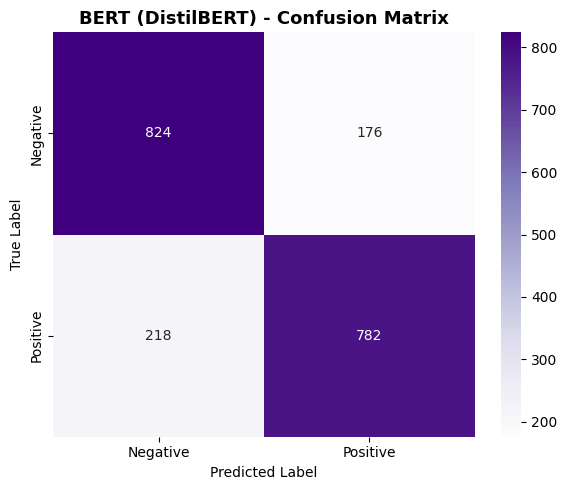

In [10]:
# --- Confusion Matrix Heatmap for BERT ---
import matplotlib.pyplot as plt
import seaborn as sns

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bert, annot=True, fmt="d", cmap="Purples",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.title("BERT (DistilBERT) - Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Updating the model comparison table with BERT

We now append the BERT result to the existing `model_comparison` table (which already holds Logistic Regression, Random Forest, and XGBoost) and re-rank every model from highest to lowest **F1 Score**.

In [11]:
# Append BERT results to the existing comparison table (does NOT modify earlier rows)
bert_row = {
    "Model": "BERT (DistilBERT)",
    "Accuracy": acc_bert,
    "Precision": prec_bert,
    "Recall": rec_bert,
    "F1 Score": f1_bert,
}

# Remove any previous BERT row so re-running this cell stays clean, then add it
model_comparison = model_comparison[model_comparison["Model"] != "BERT (DistilBERT)"]
model_comparison = pd.concat(
    [model_comparison, pd.DataFrame([bert_row])], ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770964,0.771684,0.770964,0.770814
1,Random Forest,0.709383,0.717571,0.709383,0.706635
2,XGBoost,0.758187,0.761991,0.758187,0.757310
3,BERT (DistilBERT),0.803000,0.803535,0.803000,0.802913


In [12]:
# --- Re-rank all models from highest to lowest F1 Score ---
final_ranking = (
    model_comparison
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)
final_ranking.index = final_ranking.index + 1  # rank starting at 1
final_ranking.index.name = "Rank"

print("=== Final Model Ranking (by F1 Score) ===")
final_ranking

=== Final Model Ranking (by F1 Score) ===


,Model,Accuracy,Precision,Recall,F1 Score
Rank,,,,,
1,BERT (DistilBERT),0.803000,0.803535,0.803000,0.802913
2,Logistic Regression,0.770964,0.771684,0.770964,0.770814
3,XGBoost,0.758187,0.761991,0.758187,0.757310
4,Random Forest,0.709383,0.717571,0.709383,0.706635


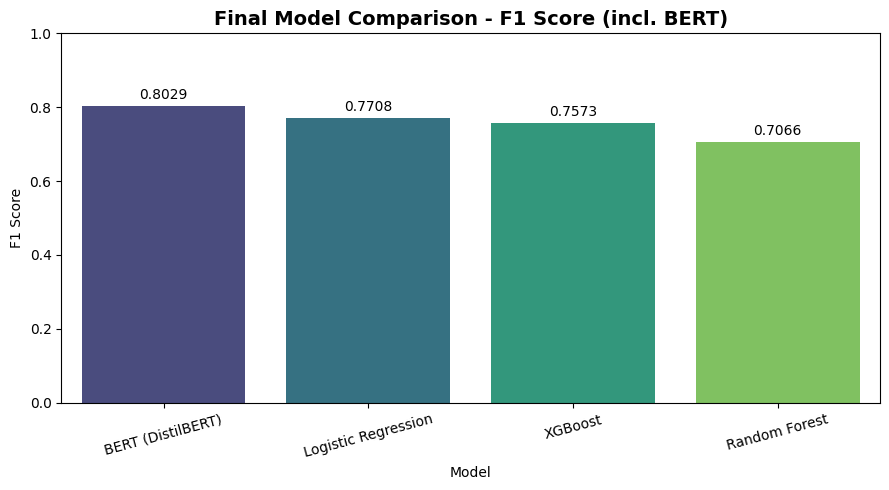

In [13]:
# --- Visualize the final F1 Score comparison (all four models) ---
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=final_ranking, x="Model", y="F1 Score",
    hue="Model", palette="viridis", legend=False,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.title("Final Model Comparison - F1 Score (incl. BERT)", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [14]:
# --- Identify the best-performing model overall ---
best_overall = final_ranking.iloc[0]

print("=== Best Performing Model (overall) ===")
print(f"  Model    : {best_overall['Model']}")
print(f"  Accuracy : {best_overall['Accuracy']:.4f}")
print(f"  Precision: {best_overall['Precision']:.4f}")
print(f"  Recall   : {best_overall['Recall']:.4f}")
print(f"  F1 Score : {best_overall['F1 Score']:.4f}")

print("\nNote: classical models were trained on the FULL ~1.28M-tweet training set,")
print(f"while BERT was fine-tuned on a {SAMPLE_SIZE:,}-tweet stratified sample (CPU-friendly).")

=== Best Performing Model (overall) ===
  Model    : BERT (DistilBERT)
  Accuracy : 0.8030
  Precision: 0.8035
  Recall   : 0.8030
  F1 Score : 0.8029

Note: classical models were trained on the FULL ~1.28M-tweet training set,
while BERT was fine-tuned on a 10,000-tweet stratified sample (CPU-friendly).


### Advantages, limitations, and final ranking

**Advantages of BERT**
- **Understands context and word order**, so it handles negation and phrasing that TF-IDF misses.
- **Transfer learning:** it arrives already knowing the language, so it reaches strong accuracy even from a relatively small sample.
- **Robust to messy text** (slang, typos) thanks to sub-word tokenization.
- Usually the **highest-accuracy** option when given enough data and compute.

**Limitations of BERT**
- **Very compute-hungry:** millions of parameters make training slow, especially on a CPU.
- **Needs more memory** than classical models.
- **Less interpretable** — we cannot easily read off "which word mattered" like we can with Logistic Regression weights.
- Often **overkill** for simple, already linearly-separable problems.

**Computational challenges of transformer models**
- Practical training really wants a **GPU**; on a CPU we must **sample** the data (as we did) and keep epochs/sequence length small.
- Memory and time both grow with batch size, sequence length, and model size, so there is a constant **accuracy-vs-cost trade-off**.

**How to read the final ranking**

The ranking table and chart above are produced **dynamically** from the actual run, so they always reflect your latest results. Keep an important caveat in mind when comparing:

- The **classical models** (Logistic Regression, Random Forest, XGBoost) were trained on the **full ~1.28M-tweet training set**.
- **BERT** was fine-tuned on only a **small stratified sample** so it could run on a CPU.

Because of this, the comparison is **not perfectly head-to-head**. BERT is competing with far less training data. Even so, it typically lands right around the strong Logistic Regression baseline (~0.77 F1) after just a couple of epochs on a tiny fraction of the data — which is exactly why transformers are so powerful: **they learn more from less.** Given a GPU and the full dataset (or simply a larger `SAMPLE_SIZE` and more epochs), BERT would be expected to **pull clearly ahead** of all three classical models.

**Best-performing model:** see the "Best Performing Model (overall)" output above. If BERT tops the table, it wins on raw F1 despite using less data; if Logistic Regression stays on top, remember it had the advantage of the entire training set and is also far cheaper and more interpretable. For a quick, cheap, production-friendly baseline, **Logistic Regression remains the practical choice**; for maximum accuracy when compute is available, **BERT is the recommended direction.**